In [1]:
import anndata
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

In [2]:
import scvi

In [3]:
!ls

figures
figures_resolvi
outs_S1_R1
outs_S1_R2
proseg_S1_R1.h5ad
proseg_S1_R2.h5ad
proseg_scanvi_xenium_breast_cancer_S1_R1_2.h5ad
proseg_xenium_breast_cancer_S1_R1_2.h5ad
query_ref_S1_R1_2.h5ad
resolvae
resolvi_proseg_to_anndata.ipynb
resolvi_script.py
scanvi_proseg_to_anndata.ipynb
scanvi_query_S1_R1_2
scanvi_ref_S1_R1_2
scanvi_script.py


# Load your data (Proseg outs)

In [4]:
proseg = anndata.AnnData(X=pd.read_csv("outs_S1_R2/expected-counts.csv.gz"))
cell_meta = pd.read_csv("outs_S1_R2/transcript-metadata.csv.gz")

/home/labs/nyosef/nathanl/mambaforge/envs/scvi/lib/python3.11/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [48]:
proseg

AnnData object with n_obs × n_vars = 118188 × 541

In [49]:
cell_meta

,transcript_id,x,y,z,observed_x,observed_y,observed_z,gene,fov,assignment,probability,background,confusion
0,281474976710656,5.240995,471.74637,14.674476,4.575770,470.25210,17.118395,ITGAX,0,112590,1.00001,0,0
1,281474976710657,9.760515,161.28400,15.992804,5.831209,161.52937,14.246363,LUM,0,5688,1.00001,0,0
2,281474976710658,3.831646,463.49808,17.004713,4.961021,463.57712,15.321023,HAVCR2,0,112590,1.00001,0,0
3,281474976710659,5.705525,251.58884,20.861742,5.634343,252.30121,14.246363,PTRHD1,0,84659,1.00001,0,0
4,281474976710660,7.115551,235.13683,15.136736,5.816967,233.52885,14.246363,RUNX1,0,84659,0.72001,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31926427,281805689296159,5204.985400,4701.65400,44.272970,5212.651400,4698.59670,38.812508,PELI1,0,7710,0.41001,1,0
31926428,281805689296161,5211.177200,5207.17530,39.865820,5213.400000,5198.68850,39.606850,CD8B,0,53291,0.97001,0,0
31926429,281805689296162,5209.150000,4700.62450,35.901638,5213.168000,4702.09900,46.065033,LUM,0,7710,0.96000,1,0
31926430,281805689296164,5209.713400,5200.67770,34.123493,5213.622600,5201.16300,38.815260,LUM,0,53291,0.93000,1,0


In [50]:
cell_avg = (
    cell_meta.drop(columns=["gene", "transcript_id"]).groupby("assignment").mean()
)

In [51]:
cell_avg = cell_avg.loc[proseg.obs.index.astype(int).intersection(cell_avg.index)]
cell_avg.index = [str(i) for i in cell_avg.index]
proseg = proseg[cell_avg.index]
proseg.obs = cell_avg
cell_meta["v"] = np.ones(cell_meta.shape[0], int)
counts = (
    cell_meta[["assignment", "gene", "v"]]
    .groupby(["assignment", "gene"])
    .sum()
    .pivot_table("v", index="assignment", columns="gene")
    .fillna(0)
)
proseg.layers["counts"] = counts.loc[proseg.obs_names.astype(int), proseg.var_names]
counts_sub = (
    cell_meta.loc[cell_meta["background"] == 0, ["assignment", "gene", "v"]]
    .groupby(["assignment", "gene"])
    .sum()
    .pivot_table("v", index="assignment", columns="gene")
    .fillna(0)
)

In [52]:
proseg

AnnData object with n_obs × n_vars = 118164 × 541
    obs: 'x', 'y', 'z', 'observed_x', 'observed_y', 'observed_z', 'fov', 'probability', 'background', 'confusion'
    layers: 'counts'

In [53]:
proseg = proseg[counts_sub.index.astype(str).intersection(proseg.obs_names)].copy()

In [54]:
proseg

AnnData object with n_obs × n_vars = 118159 × 541
    obs: 'x', 'y', 'z', 'observed_x', 'observed_y', 'observed_z', 'fov', 'probability', 'background', 'confusion'
    layers: 'counts'

In [55]:
# new_indices = [
#     16873,
#     63868,
#     102578,
#     121788,
#     123933,
#     124023,
#     126753,
#     128327,
#     129848,
#     129987,
# ]
# # Create a new DataFrame with all zeros and the specified indices
# new_rows = pd.DataFrame(0, index=new_indices, columns=counts_sub.columns)

# # Append the new rows to the original DataFrame
# counts_sub = counts_sub.append(new_rows)
proseg.layers["counts_wo_bg"] = counts_sub.loc[
    proseg.obs_names.astype(int), proseg.var_names
] #run nicheVI here - filter cells with less than 20 counts smth like that

#but do cell typing with proseg.x 

In [56]:
proseg.layers["counts_wo_bg"].sum(axis=1).min()

1.0

In [57]:
cells_subset, number_per_cell = sc.pp.filter_cells(proseg.layers["counts_wo_bg"], min_counts=10)

In [58]:
proseg.var_names  #.startswith('BLANK_')

Index(['ITGAX', 'LUM', 'HAVCR2', 'PTRHD1', 'RUNX1', 'TCIM',
       'NegControlProbe_00003', 'GLIPR1', 'BLANK_0434', 'DAPK3',
       ...
       'BLANK_0465', 'BLANK_0278', 'BLANK_0451', 'BLANK_0072', 'BLANK_0069',
       'BLANK_0272', 'BLANK_0414', 'BLANK_0449', 'NegControlCodeword_0501',
       'BLANK_0357'],
      dtype='object', length=541)

In [59]:
# proseg_new.obsm["blank_probes"] = pd.DataFrame(
#     proseg_new[:, proseg_new.var_names.str.contains("BLANK")].layers["counts"],
#     columns=proseg_new.var_names[proseg_new.var_names.str.contains("BLANK")],
#     index=proseg_new.obs_names,
# )
# proseg_new.obsm["neg_probe"] = pd.DataFrame(
#     proseg_new[:, proseg_new.var_names.str.contains("NegControlProbe")].layers[
#         "counts"
#     ],
#     columns=proseg_new.var_names[proseg_new.var_names.str.contains("NegControlProbe")],
#     index=proseg_new.obs_names,
# )
# proseg_new.obsm["neg_codeword"] = pd.DataFrame(
#     proseg_new[:, proseg_new.var_names.str.contains("NegControlCodeword")].layers[
#         "counts"
#     ],
#     columns=proseg_new.var_names[
#         proseg_new.var_names.str.contains("NegControlCodeword")
#     ],
#     index=proseg_new.obs_names,
# )

In [67]:
adata_orig = sc.read_h5ad("../xenium_breast_cancer_S1_R1_2.h5ad")
adata_orig

AnnData object with n_obs × n_vars = 281780 × 313
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample', 'cell_type', 'n_genes', 'n_counts', '_scvi_batch', '_scvi_labels'
    var: 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'pca', 'simvi_train_mask', 'simvi_val_mask'
    obsm: 'X_pca', 'X_scVI', 'X_scVI_MDE', 'banksy_pc_20_lambda_0.0', 'banksy_pc_20_lambda_0.2', 'banksy_pc_20_lambda_0.5', 'simvi_both', 'simvi_both_08', 'simvi_both_MDE', 'simvi_both_MDE_08', 'simvi_interact', 'simvi_interact_08', 'simvi_interact_MDE', 'simvi_interact_MDE_08', 'simvi_intrinsic', 'simvi_intrinsic_08', 'simvi_intrinsic_MDE', 'simvi_intrinsic_MDE_08', 'spatial'
    varm: 'PCs'
    layers: 'counts'

In [87]:
adata_orig.obs["cell_type"].unique().tolist()

['DCIS_2',
 'Macrophages_1',
 'Unlabeled',
 'Invasive_Tumor',
 'Stromal',
 'DCIS_1',
 'Myoepi_ACTA2+',
 'CD8+_T_Cells',
 'Endothelial',
 'Prolif_Invasive_Tumor',
 'T_Cell_&_Tumor_Hybrid',
 'Mast_Cells',
 'CD4+_T_Cells',
 'B_Cells',
 'Macrophages_2',
 'Stromal_&_T_Cell_Hybrid',
 'Perivascular-Like',
 'LAMP3+_DCs',
 'IRF7+_DCs',
 'Myoepi_KRT15+']

In [61]:
adata_orig.layers["counts"].sum(axis=1).min()

10.0

In [62]:
proseg = proseg[cells_subset][:, adata_orig.var_names].copy()

In [63]:
proseg

AnnData object with n_obs × n_vars = 117314 × 313
    obs: 'x', 'y', 'z', 'observed_x', 'observed_y', 'observed_z', 'fov', 'probability', 'background', 'confusion'
    layers: 'counts', 'counts_wo_bg'

In [64]:
proseg.write_h5ad("proseg_S1_R2.h5ad")

## Build anndata 

In [88]:
!pwd

/home/labs/nyosef/Collaboration/SpatialDatasets/xenium/human_breast_cancer/proseg


In [69]:
adata_R1 = sc.read_h5ad("proseg_S1_R1.h5ad")
adata_R2 = sc.read_h5ad("proseg_S1_R2.h5ad")


adata_proseg = ad.concat([adata_R1, adata_R2], index_unique="_", label="sample")

adata_proseg.write_h5ad("proseg_xenium_breast_cancer_S1_R1_2.h5ad")

adata_proseg

/home/labs/nyosef/nathanl/mambaforge/envs/scvi/lib/python3.11/site-packages/anndata/_core/merge.py:1015: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  concat_indices = concat_indices.str.cat(label_col.map(str), sep=index_unique)


AnnData object with n_obs × n_vars = 278683 × 313
    obs: 'x', 'y', 'z', 'observed_x', 'observed_y', 'observed_z', 'fov', 'probability', 'background', 'confusion', 'sample'
    layers: 'counts', 'counts_wo_bg'

# Load AnnData and pre_process

In [5]:
adata_proseg = sc.read_h5ad("proseg_xenium_breast_cancer_S1_R1_2.h5ad")

In [6]:
sc.pp.normalize_total(adata_proseg, target_sum=1e4)
sc.pp.log1p(adata_proseg)

sc.tl.pca(adata_proseg)

In [7]:
adata_proseg.obsm["MDE_pca"] = scvi.model.utils.mde(adata_proseg.obsm["X_pca"])

INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


In [8]:
leiden_resolution = 2

In [9]:
sc.pp.neighbors(adata_proseg, use_rep="X_pca")
sc.tl.leiden(adata_proseg, resolution=leiden_resolution, key_added=f"leiden_pca_{leiden_resolution}")

/home/labs/nyosef/nathanl/mambaforge/envs/scvi/lib/python3.11/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/labs/nyosef/nathanl/mambaforge/envs/scvi/lib/python3.11/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/labs/nyosef/nathanl/mambaforge/envs/scvi

/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


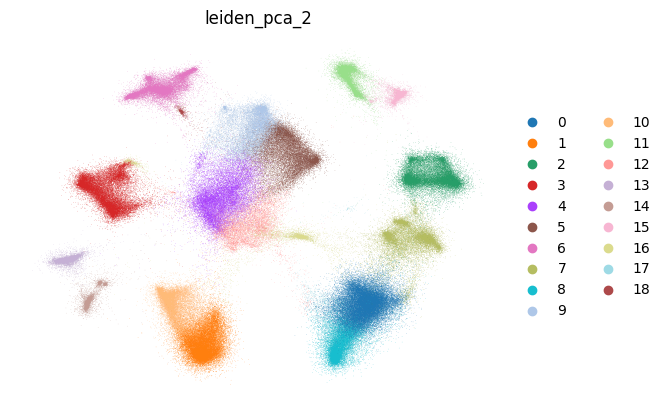

In [10]:
sc.pl.embedding(
    adata_proseg,
    basis="MDE_pca",
    color=f"leiden_pca_{leiden_resolution}",
    frameon=False,
    ncols=1,
    color_map="Paired",
    # groups=["CD8+_T_Cells"],
)

In [11]:
adata_proseg.write_h5ad("proseg_xenium_breast_cancer_S1_R1_2.h5ad")

# DE - annotation 

In [20]:
adata_proseg = sc.read_h5ad("proseg_xenium_breast_cancer_S1_R1_2.h5ad")

adata_proseg

AnnData object with n_obs × n_vars = 278683 × 313
    obs: 'x', 'y', 'z', 'observed_x', 'observed_y', 'observed_z', 'fov', 'probability', 'background', 'confusion', 'sample', 'leiden_pca_2'
    uns: 'leiden', 'leiden_pca_2_colors', 'log1p', 'neighbors', 'pca'
    obsm: 'MDE_pca', 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'counts_wo_bg'
    obsp: 'connectivities', 'distances'

In [21]:
adata_orig = sc.read_h5ad("../xenium_breast_cancer_S1_R1_2.h5ad")

adata_orig

AnnData object with n_obs × n_vars = 281780 × 313
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample', 'cell_type', 'n_genes', 'n_counts', '_scvi_batch', '_scvi_labels'
    var: 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'pca', 'simvi_train_mask', 'simvi_val_mask'
    obsm: 'X_pca', 'X_scVI', 'X_scVI_MDE', 'banksy_pc_20_lambda_0.0', 'banksy_pc_20_lambda_0.2', 'banksy_pc_20_lambda_0.5', 'simvi_both', 'simvi_both_08', 'simvi_both_MDE', 'simvi_both_MDE_08', 'simvi_interact', 'simvi_interact_08', 'simvi_interact_MDE', 'simvi_interact_MDE_08', 'simvi_intrinsic', 'simvi_intrinsic_08', 'simvi_intrinsic_MDE', 'simvi_intrinsic_MDE_08', 'spatial'
    varm: 'PCs'
    layers: 'counts'

In [22]:
adata_full = sc.read_h5ad("query_ref_S1_R1_2.h5ad")

adata_full


SCANVI_LATENT_KEY = "X_scANVI"
SCANVI_PREDICTIONS_KEY = "predictions_scanvi"

/home/labs/nyosef/nathanl/mambaforge/envs/scvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1830: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
sc.tl.rank_genes_groups(adata_proseg, groupby="leiden_pca_2", method="wilcoxon", key_added="rank_genes_groups_wilcoxon_pca_2", pts=True)

/home/labs/nyosef/nathanl/mambaforge/envs/scvi/lib/python3.11/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()


/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:133: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()
/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


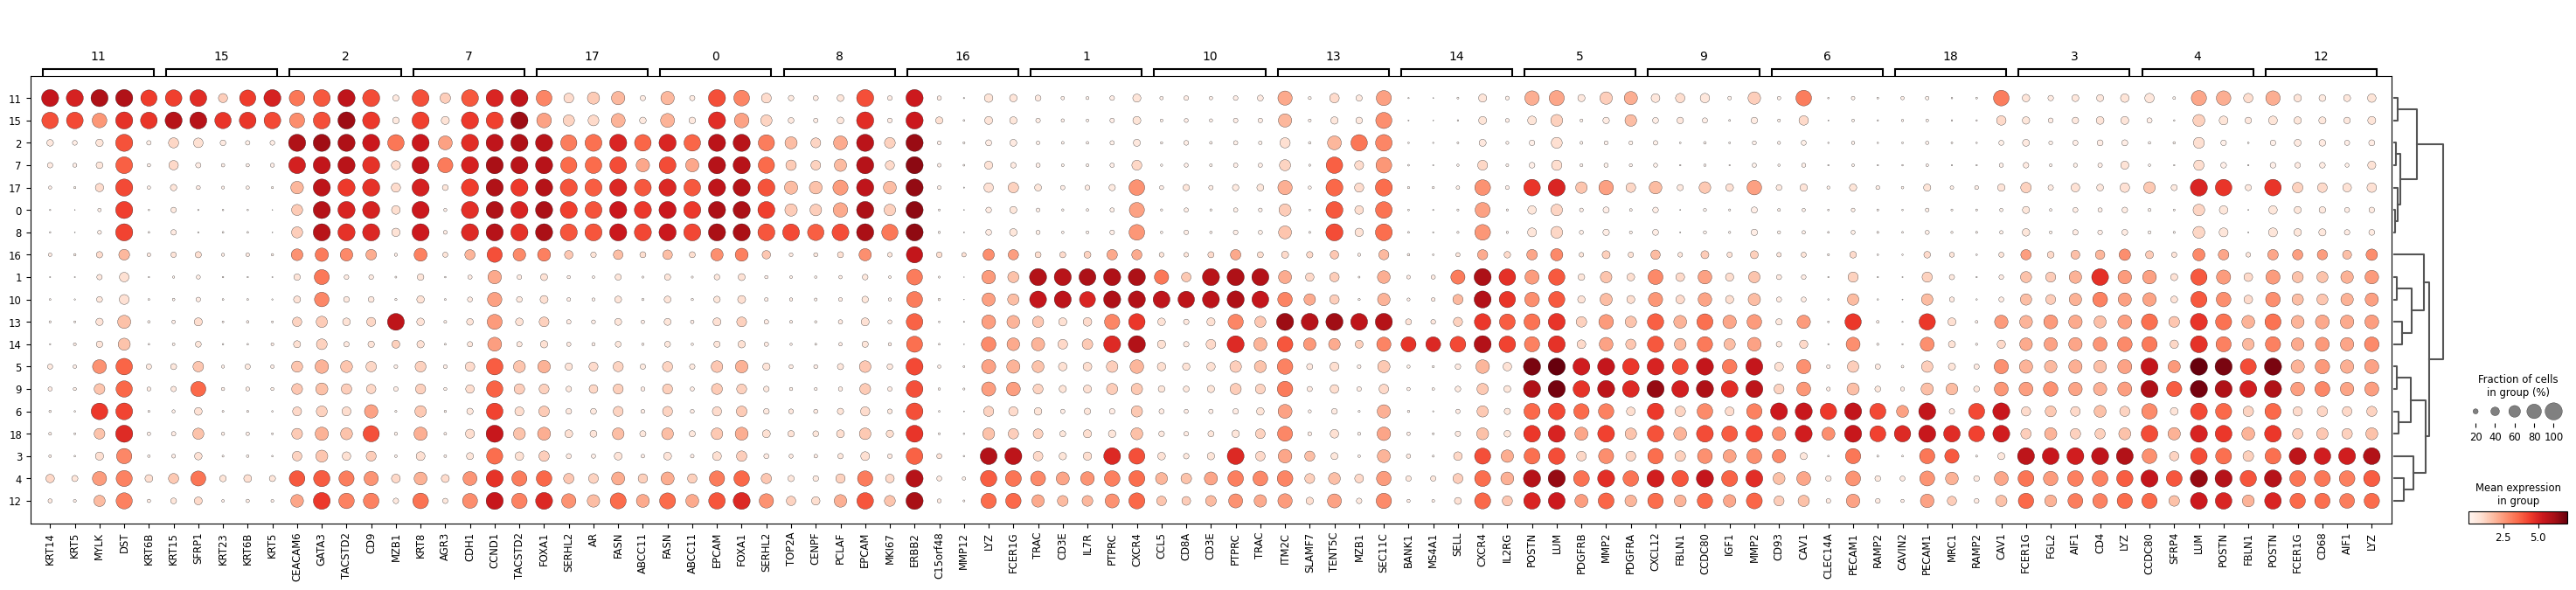

In [6]:
sc.pl.rank_genes_groups_dotplot(
    adata_proseg,
    groupby="leiden_pca_2",
    # standard_scale="var",
    n_genes=5,
    key="rank_genes_groups_wilcoxon_pca_2",
)

/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, 

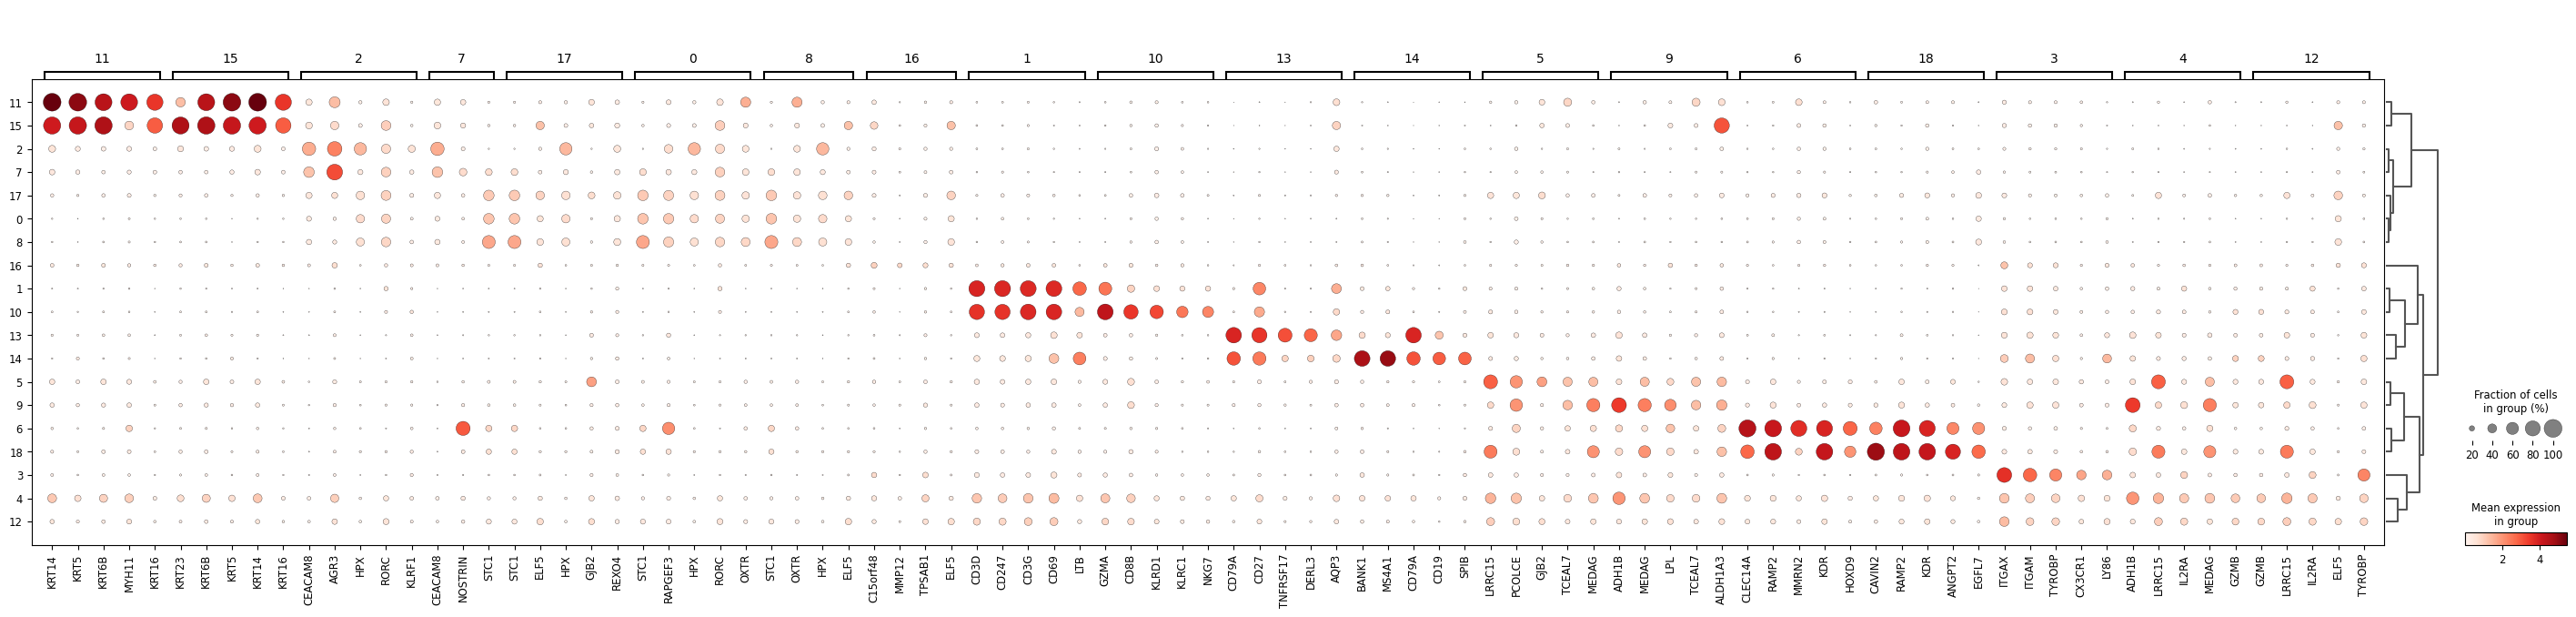

In [7]:
sc.tl.filter_rank_genes_groups(
    adata_proseg,
    min_in_group_fraction=0.1,
    max_out_group_fraction=0.2,
    key="rank_genes_groups_wilcoxon_pca_2",
    key_added="rank_genes_groups_filtered_wilcoxon_pca_2",
)


sc.pl.rank_genes_groups_dotplot(
    adata_proseg,
    groupby="leiden_pca_2",
    # standard_scale="var",
    n_genes=5,
    key="rank_genes_groups_filtered_wilcoxon_pca_2",
)

In [8]:
# del adata_proseg.uns["log1p"]

adata_proseg.var_names # = adata_proseg.var

Index(['ABCC11', 'ACTA2', 'ACTG2', 'ADAM9', 'ADGRE5', 'ADH1B', 'ADIPOQ',
       'AGR3', 'AHSP', 'AIF1',
       ...
       'TUBB2B', 'TYROBP', 'UCP1', 'USP53', 'VOPP1', 'VWF', 'WARS', 'ZEB1',
       'ZEB2', 'ZNF562'],
      dtype='object', length=313)

In [9]:
sc.get.rank_genes_groups_df(
    adata_proseg,
    # key="rank_genes_groups_filtered_wilcoxon_pca_2",
    key="rank_genes_groups_filtered_wilcoxon_pca_2",
    group="1",
    pval_cutoff=0.05,
    log2fc_min=0.1,
)  # ["names"].tolist()

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,CD3D,207.049423,6.148511,0.000000e+00,0.000000e+00,0.865504,0.174921
1,CD247,206.819824,6.084652,0.000000e+00,0.000000e+00,0.866761,0.174731
2,CD3G,201.389679,5.881983,0.000000e+00,0.000000e+00,0.856708,0.182718
3,CD69,195.971130,5.693148,0.000000e+00,0.000000e+00,0.849701,0.195454
4,LTB,164.550522,5.348392,0.000000e+00,0.000000e+00,0.692624,0.113940
5,CCR7,159.374695,4.946277,0.000000e+00,0.000000e+00,0.698983,0.158544
6,CTLA4,143.371552,5.292263,0.000000e+00,0.000000e+00,0.605384,0.102154
7,GZMA,136.056000,4.091520,0.000000e+00,0.000000e+00,0.649176,0.159047
8,CD27,133.683304,3.922070,0.000000e+00,0.000000e+00,0.628575,0.146572
9,TIGIT,102.317200,4.253703,0.000000e+00,0.000000e+00,0.449754,0.082881


## compare with cell types

In [9]:
sc.tl.rank_genes_groups(
    adata_orig,
    groupby="cell_type",
    method="wilcoxon",
    key_added="rank_genes_groups_wilcoxon_cell_type",
    use_raw=False,
    pts=True,
    n_genes=None,
)

/home/labs/nyosef/nathanl/mambaforge/envs/scvi/lib/python3.11/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()


/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:133: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()
/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


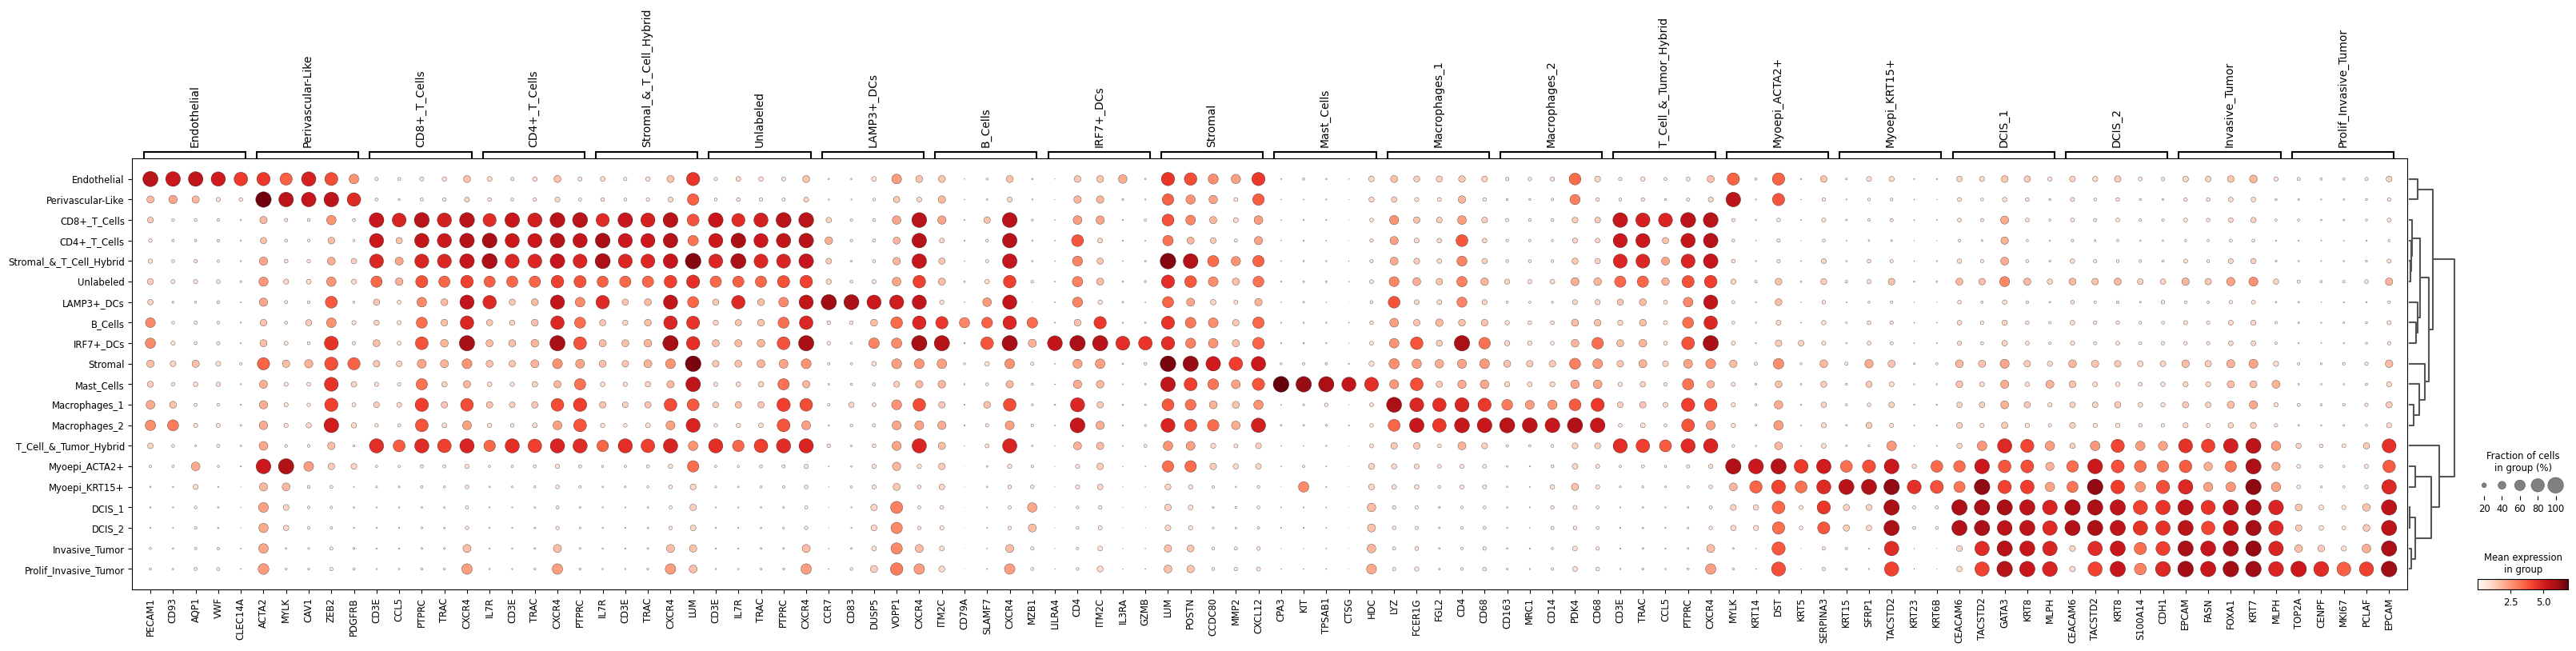

In [12]:
sc.pl.rank_genes_groups_dotplot(
    adata_orig, groupby="cell_type", standard_scale=None, n_genes=5, key="rank_genes_groups_wilcoxon_cell_type"
)

Set the Unlabeled 

categories: B_Cells, CD4+_T_Cells, CD8+_T_Cells, etc.
var_group_labels: B_Cells, CD4+_T_Cells, CD8+_T_Cells, etc.


/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, 

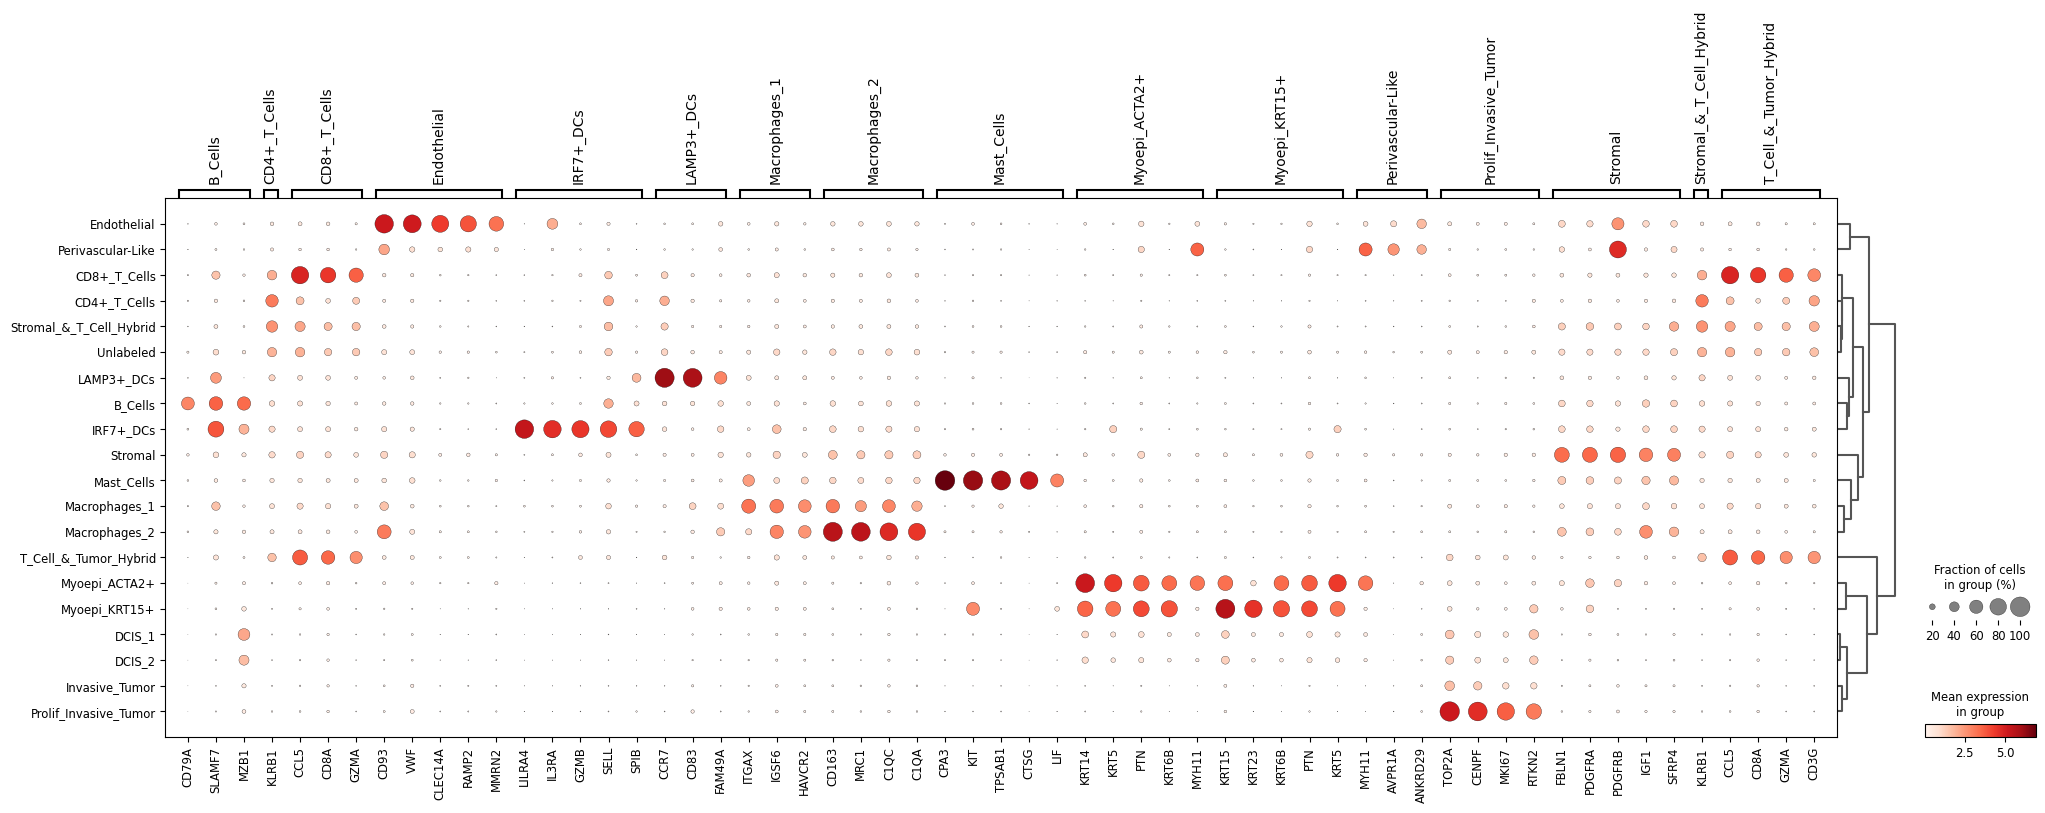

In [13]:
sc.tl.filter_rank_genes_groups(
    adata_orig,
    min_in_group_fraction=0.1,
    max_out_group_fraction=0.2,
    key="rank_genes_groups_wilcoxon_cell_type",
    key_added="rank_genes_groups_filtered_wilcoxon_cell_type",
)


sc.pl.rank_genes_groups_dotplot(
    adata_orig,
    groupby="cell_type",
    # standard_scale="var",
    n_genes=5,
    key="rank_genes_groups_filtered_wilcoxon_cell_type",
)

In [19]:
df_orig = sc.get.rank_genes_groups_df(
    adata_orig,
    # key="rank_genes_groups_filtered_wilcoxon_pca_2",
    key="rank_genes_groups_wilcoxon_cell_type",
    group=None,
    pval_cutoff=0.05,
    log2fc_min=0.1,
)  # ["names"].tolist()


adata_proseg_scanvi = adata_full[adata_full.obs.batch == "Query-proseg"].copy()

sc.tl.rank_genes_groups(
    adata_proseg,
    groupby=SCANVI_PREDICTIONS_KEY,
    method="wilcoxon",
    use_raw=False,
    key_added="rank_genes_groups_wilcoxon_predicted_cell_type",
    pts=True,
    n_genes=None,
)

df_proseg = sc.get.rank_genes_groups_df(
    adata_proseg,
    key="rank_genes_groups_wilcoxon_predicted_cell_type",
    group=None,
    pval_cutoff=0.05,
    log2fc_min=0.1,
)  # ["names"].tolist()

/home/labs/nyosef/nathanl/mambaforge/envs/scvi/lib/python3.11/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [16]:
df_orig_top_genes = (
    df_orig.groupby("group")
    .apply(lambda x: x.nlargest(5, "logfoldchanges"))
    .reset_index(drop=True)
    .sort_values(["group", "logfoldchanges"], ascending=[True, False])
)[["group", "names", "logfoldchanges", "pct_nz_group", "pct_nz_reference"]]

df_proseg_top_genes = (
    df_proseg.groupby("group")
    .apply(lambda x: x.nlargest(5, "logfoldchanges"))
    .reset_index(drop=True)
    .sort_values(["group", "logfoldchanges"], ascending=[True, False])
)[["group", "names", "logfoldchanges", "pct_nz_group", "pct_nz_reference"]]

df_proseg_top_genes.iloc[75:100]

,group,names,logfoldchanges,pct_nz_group,pct_nz_reference
75,Prolif_Invasive_Tumor,TOP2A,6.885921,0.988310,0.318235
76,Prolif_Invasive_Tumor,CENPF,6.596024,0.964333,0.279083
77,Prolif_Invasive_Tumor,MKI67,5.210773,0.951807,0.320533
78,Prolif_Invasive_Tumor,PCLAF,5.025115,0.966003,0.414636
79,Prolif_Invasive_Tumor,EPCAM,4.449199,0.999523,0.682697
80,Stromal,POSTN,6.605143,0.990868,0.599318
81,Stromal,CCDC80,6.437082,0.978265,0.443728
82,Stromal,LUM,6.211295,0.997382,0.762057
83,Stromal,MMP2,6.018164,0.972280,0.478439
84,Stromal,FBLN1,5.968161,0.893650,0.267594


In [17]:
df_orig_top_genes.iloc[75:]

,group,names,logfoldchanges,pct_nz_group,pct_nz_reference
75,Prolif_Invasive_Tumor,TOP2A,7.141171,0.991468,0.184980
76,Prolif_Invasive_Tumor,CENPF,7.126493,0.946676,0.134494
77,Prolif_Invasive_Tumor,MKI67,5.888907,0.851226,0.122540
78,Prolif_Invasive_Tumor,PCLAF,5.446852,0.881621,0.217408
79,Prolif_Invasive_Tumor,RTKN2,4.542710,0.728582,0.158100
80,Stromal,CCDC80,6.139750,0.905258,0.253868
81,Stromal,POSTN,6.020592,0.972120,0.433541
82,Stromal,LUM,5.802821,0.992936,0.520546
83,Stromal,FBLN1,5.688375,0.694459,0.101846
84,Stromal,MMP2,5.647336,0.822719,0.200417


In [ ]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_fscore_support,
    roc_auc_score,
)


def _get_precision_recall_f1(ground_truth: np.ndarray, pred: np.ndarray):
    precision, recall, f1, _ = precision_recall_fscore_support(
        ground_truth, pred, average="binary"
    )
    return precision, recall, f1


groups = df_orig_top_genes["group"].unique()
n_top_genes_fallback = 100
gene_overlap_f1s = []

for g in groups:
    raw_group_data = sc.get.rank_genes_groups_df(
        adata_orig,
        key="rank_genes_groups_wilcoxon_cell_type",
        group=g,
    )

    sample_group_data = sc.get.rank_genes_groups_df(
        adata_proseg,
        key="rank_genes_groups_wilcoxon_predicted_cell_type",
        group=g,
    )

    # compute gene overlaps
    all_genes = raw_group_data.index  # order doesn't matter here
    top_genes_raw = raw_group_data[:n_top_genes_fallback].index
    top_genes_sample = sample_group_data[:n_top_genes_fallback].index
    true_genes = np.array([0 if g not in top_genes_raw else 1 for g in all_genes])
    pred_genes = np.array([0 if g not in top_genes_sample else 1 for g in all_genes])
    gene_overlap_f1s.append(_get_precision_recall_f1(true_genes, pred_genes)[2])

gene_overlap_f1s

[1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

# SCANVI transfer

In [5]:
adata_full.obs["cell_type"]

0_0                    ignore
1_0                    ignore
2_0                    ignore
3_0                    ignore
4_0                    ignore
                  ...        
118748_1          Endothelial
118749_1          Endothelial
118750_1          Endothelial
118751_1          Endothelial
118752_1    Perivascular-Like
Name: cell_type, Length: 560463, dtype: category
Categories (21, object): ['B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', ..., 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid', 'Unlabeled', 'ignore']

In [6]:
adata_full.obs.batch.unique()

['Query-proseg', 'Reference-xenium']
Categories (2, object): ['Query-proseg', 'Reference-xenium']

In [7]:
adata_full.obs["cell_type"][
    adata_full.obs.batch == "Reference-xenium"
].value_counts() / len(
    adata_full.obs["cell_type"][adata_full.obs.batch == "Reference-xenium"]
)

cell_type
Stromal                    0.283860
Invasive_Tumor             0.177553
DCIS_2                     0.076964
DCIS_1                     0.071236
Macrophages_1              0.068163
Endothelial                0.055462
CD4+_T_Cells               0.050979
Myoepi_ACTA2+              0.046618
CD8+_T_Cells               0.042178
B_Cells                    0.031127
Unlabeled                  0.026900
Prolif_Invasive_Tumor      0.019966
Myoepi_KRT15+              0.019533
Macrophages_2              0.011342
Perivascular-Like          0.004951
Stromal_&_T_Cell_Hybrid    0.004081
IRF7+_DCs                  0.003169
T_Cell_&_Tumor_Hybrid      0.002970
LAMP3+_DCs                 0.001789
Mast_Cells                 0.001157
ignore                     0.000000
Name: count, dtype: float64

In [28]:
adata_full.obs["predictions_scanvi"][
    adata_full.obs.batch == "Reference-xenium"
].value_counts() / len(
    adata_full.obs["predictions_scanvi"][adata_full.obs.batch == "Reference-xenium"]
)

predictions_scanvi
Stromal                    0.284928
Invasive_Tumor             0.176631
DCIS_2                     0.077504
DCIS_1                     0.072415
Macrophages_1              0.068848
Endothelial                0.056072
CD4+_T_Cells               0.053048
Myoepi_ACTA2+              0.046440
CD8+_T_Cells               0.042409
B_Cells                    0.031801
Prolif_Invasive_Tumor      0.020612
Unlabeled                  0.020562
Myoepi_KRT15+              0.019817
Macrophages_2              0.011289
Perivascular-Like          0.005408
IRF7+_DCs                  0.003201
Stromal_&_T_Cell_Hybrid    0.002953
T_Cell_&_Tumor_Hybrid      0.002949
LAMP3+_DCs                 0.001892
Mast_Cells                 0.001221
Name: count, dtype: float64

In [29]:
adata_full.obs["predictions_scanvi"][
    adata_full.obs.batch == "Query-proseg"
].value_counts() / len(adata_full.obs["predictions_scanvi"][adata_full.obs.batch == "Query-proseg"])

predictions_scanvi
Stromal                    0.244012
Invasive_Tumor             0.178712
Macrophages_1              0.075153
DCIS_1                     0.071888
CD8+_T_Cells               0.068002
CD4+_T_Cells               0.066097
DCIS_2                     0.062950
Endothelial                0.054478
Myoepi_ACTA2+              0.041126
B_Cells                    0.039755
Prolif_Invasive_Tumor      0.030081
Myoepi_KRT15+              0.018598
Macrophages_2              0.018408
Unlabeled                  0.013011
Perivascular-Like          0.008379
IRF7+_DCs                  0.003560
LAMP3+_DCs                 0.001898
Stromal_&_T_Cell_Hybrid    0.001708
Mast_Cells                 0.001385
T_Cell_&_Tumor_Hybrid      0.000800
Name: count, dtype: float64

In [30]:
adata_proseg.obsm[SCANVI_LATENT_KEY + "_MDE_proseg"] = scvi.model.utils.mde(
    adata_full.obsm[SCANVI_LATENT_KEY][adata_full.obs.batch == "Query-proseg"]
)

adata_orig.obsm[SCANVI_LATENT_KEY + "_MDE_orig"] = scvi.model.utils.mde(
    adata_full.obsm[SCANVI_LATENT_KEY][adata_full.obs.batch == "Reference-xenium"]
)

adata_proseg.obs[SCANVI_PREDICTIONS_KEY]  = adata_full.obs[SCANVI_PREDICTIONS_KEY][adata_full.obs.batch == "Query-proseg"].values
adata_orig.obs[SCANVI_PREDICTIONS_KEY]  = adata_full.obs[SCANVI_PREDICTIONS_KEY][adata_full.obs.batch == "Reference-xenium"].values

INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


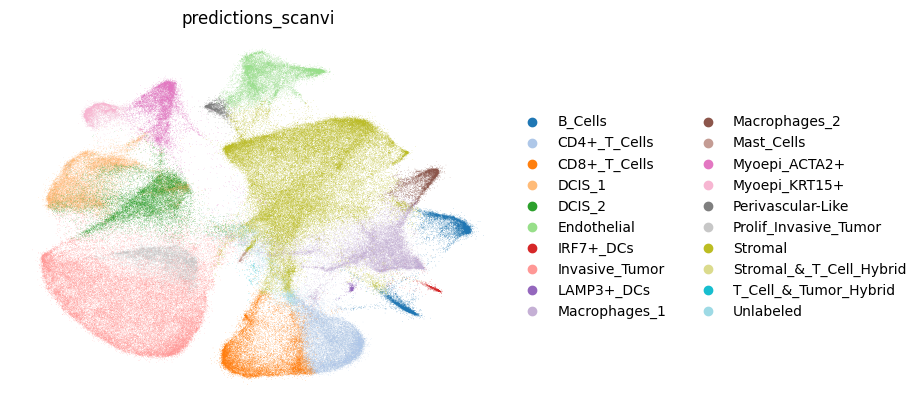

In [31]:
sc.pl.embedding(
    adata_proseg,
    basis=SCANVI_LATENT_KEY + "_MDE_proseg",
    # color=[setup.CELL_TYPE],
    color=[SCANVI_PREDICTIONS_KEY],
    frameon=False,
    ncols=1,
    palette="tab20",
    show=False,
)

plt.savefig("figures/proseg_mde.png", bbox_inches="tight", dpi=1000)

/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


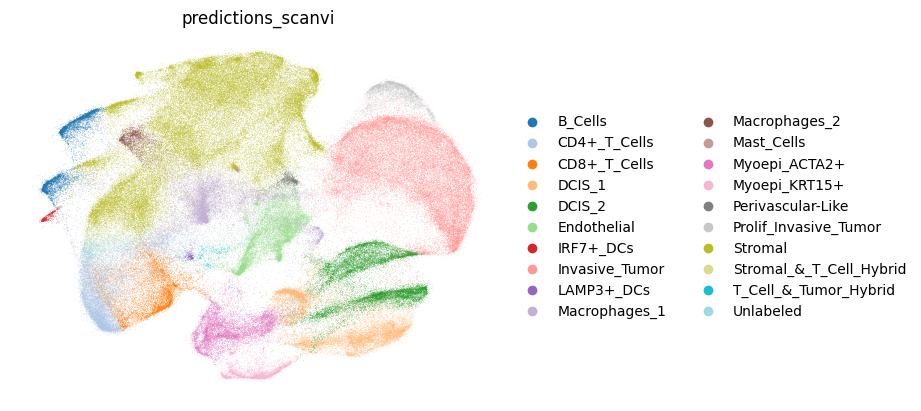

In [22]:
sc.pl.embedding(
    adata_orig,
    basis=SCANVI_LATENT_KEY + "_MDE_orig",
    # color=[setup.CELL_TYPE],
    color=[SCANVI_PREDICTIONS_KEY],
    frameon=False,
    ncols=1,
    palette="tab20",
    show=False,
)

plt.savefig("figures/orig_mde_pred.png", bbox_inches="tight", dpi=1000)

/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


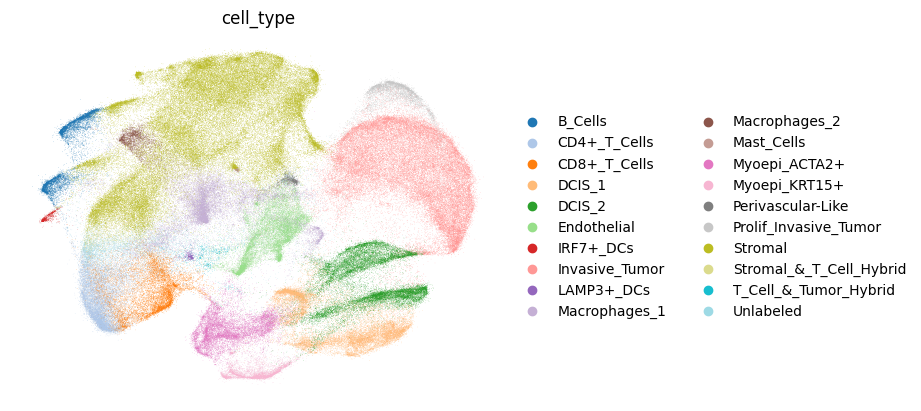

In [23]:
sc.pl.embedding(
    adata_orig,
    basis=SCANVI_LATENT_KEY + "_MDE_orig",
    # color=[setup.CELL_TYPE],
    color=["cell_type"],
    frameon=False,
    ncols=1,
    palette="tab20",
    show=False,
)

plt.savefig("figures/orig_mde_cell_type.png", bbox_inches="tight", dpi=1000)

# Checks on the PROSEG annotated file

In [23]:
adata_proseg

AnnData object with n_obs × n_vars = 278683 × 313
    obs: 'x', 'y', 'z', 'observed_x', 'observed_y', 'observed_z', 'fov', 'probability', 'background', 'confusion', 'sample', 'leiden_pca_2'
    uns: 'leiden', 'leiden_pca_2_colors', 'log1p', 'neighbors', 'pca'
    obsm: 'MDE_pca', 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'counts_wo_bg'
    obsp: 'connectivities', 'distances'

In [24]:
adata_proseg_scanvi

AnnData object with n_obs × n_vars = 278683 × 313
    obs: 'sample', '_scvi_batch', 'cell_type', '_scvi_labels', 'batch', 'predictions_scanvi'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_pca', 'X_scANVI', 'X_scANVI_MDE'
    layers: 'counts'

In [28]:
adata_proseg_scanvi.layers["counts_wo_bg"] = adata_proseg.layers["counts_wo_bg"].copy()
adata_proseg_scanvi.obs[
    [
        "x",
        "y",
        "z",
        "observed_x",
        "observed_y",
        "observed_z",
        "fov",
        "probability",
        "background",
        "confusion",
    ]
] = adata_proseg.obs[
    [
        "x",
        "y",
        "z",
        "observed_x",
        "observed_y",
        "observed_z",
        "fov",
        "probability",
        "background",
        "confusion",
    ]
].copy()

In [40]:
adata_proseg_scanvi.X = adata_proseg.layers["counts"].copy()

In [41]:
sc.pp.filter_cells(adata_proseg_scanvi, min_counts=10)

In [44]:
adata_proseg_scanvi.layers["counts"].sum(axis=1).min()

10.0

In [58]:
adata_proseg_scanvi.obsm["observed_spatial"] = adata_proseg_scanvi.obs[
    ["observed_x", "observed_y"]
].values

adata_proseg_scanvi.obsm["spatial"] = adata_proseg_scanvi.obs[["x", "y"]].values

In [60]:
adata_proseg_scanvi

AnnData object with n_obs × n_vars = 278658 × 313
    obs: 'sample', '_scvi_batch', 'cell_type', '_scvi_labels', 'batch', 'predictions_scanvi', 'x', 'y', 'z', 'observed_x', 'observed_y', 'observed_z', 'fov', 'probability', 'background', 'confusion', 'n_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_pca', 'X_scANVI', 'X_scANVI_MDE', 'spatial', 'observed_spatial'
    layers: 'counts', 'counts_wo_bg'

/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_utils.py:429: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_utils.py:429: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/labs/nyosef/nathanl/.local/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1216

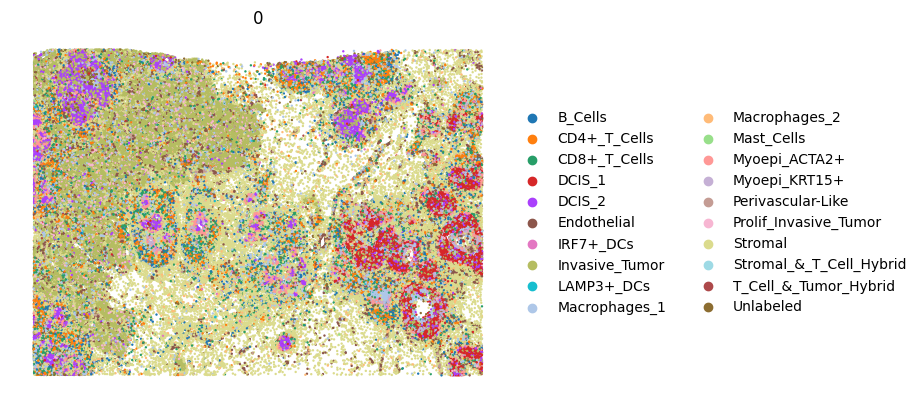

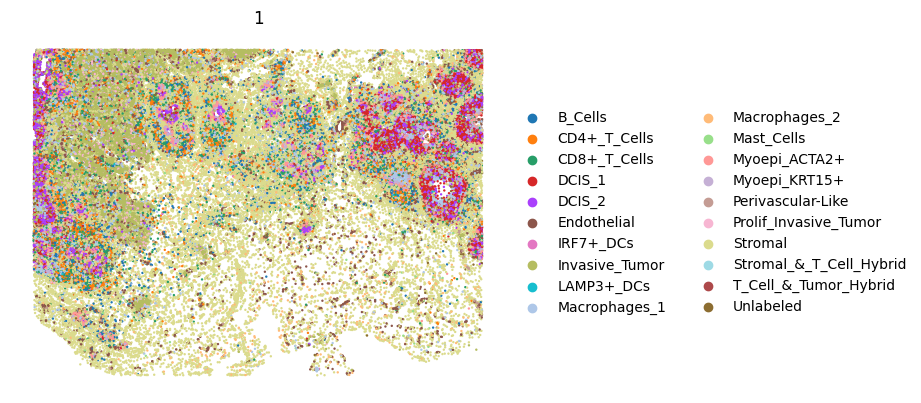

In [56]:
for sample in adata_proseg_scanvi.obs["sample"].unique()[:]:
    # with plt.rc_context():
    sc.pl.spatial(
        adata_proseg_scanvi[adata_proseg_scanvi.obs["sample"] == sample],
        spot_size=40,
        color=[SCANVI_PREDICTIONS_KEY],
        # color=[setup.NICHE],
        ncols=2,
        frameon=False,
        title=sample,
        cmap="Paired",
        show=False,
    )

    plt.savefig("figures/spatial_breast.png", bbox_inches="tight", dpi=1000)

In [31]:
adata_proseg_scanvi.write_h5ad("proseg_scanvi_xenium_breast_cancer_S1_R1_2.h5ad")

In [4]:
adata_proseg_scanvi = sc.read_h5ad("proseg_scanvi_xenium_breast_cancer_S1_R1_2.h5ad")

In [5]:
adata_proseg_scanvi

AnnData object with n_obs × n_vars = 278658 × 313
    obs: 'sample', '_scvi_batch', 'cell_type', '_scvi_labels', 'batch', 'predictions_scanvi', 'x', 'y', 'z', 'observed_x', 'observed_y', 'observed_z', 'fov', 'probability', 'background', 'confusion', 'n_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_pca', 'X_scANVI', 'X_scANVI_MDE', 'observed_spatial', 'spatial'
    layers: 'counts', 'counts_wo_bg'

In [7]:
sc.pp.normalize_total(adata_proseg_scanvi, target_sum=1e4)
sc.pp.log1p(adata_proseg_scanvi)


sc.tl.pca(adata_proseg_scanvi)

In [9]:
adata_proseg_scanvi.layers["counts"]

array([[ 2., 12.,  0., ...,  0.,  5.,  1.],
       [ 7.,  0.,  5., ...,  0.,  0.,  4.],
       [ 4.,  2.,  6., ...,  0.,  0.,  2.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  1.,  0., ...,  0.,  2.,  0.]])

In [10]:
adata_proseg_scanvi.write_h5ad("proseg_scanvi_xenium_breast_cancer_S1_R1_2.h5ad")